In [1]:
# Week 2 - End-to-End Machine Learning Pipeline

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [3]:
# Data Loading

df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [4]:
df.shape

(2640, 12)

In [5]:
df.columns

Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [7]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [8]:
df.isnull().sum()

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.drop_duplicates(inplace=True)
df.isnull().sum()

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

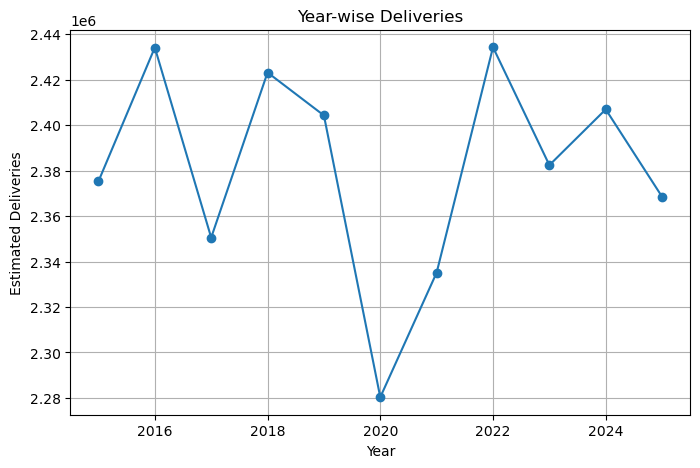

In [11]:
# Exploratory Data Analysis

yearly = df.groupby("Year")["Estimated_Deliveries"].sum()
plt.figure(figsize=(8,5))
plt.plot(yearly.index, yearly.values, marker="o")
plt.title("Year-wise Deliveries")
plt.xlabel("Year")
plt.ylabel("Estimated Deliveries")
plt.grid(True)
plt.show()


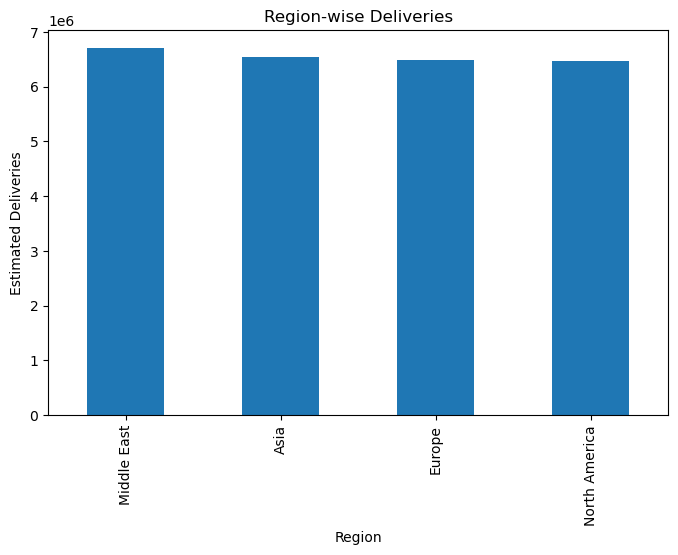

In [12]:
region = (
    df.groupby("Region")["Estimated_Deliveries"]
      .sum()
      .sort_values(ascending=False)
)
plt.figure(figsize=(8,5))
region.plot(kind="bar")
plt.title("Region-wise Deliveries")
plt.ylabel("Estimated Deliveries")
plt.show()

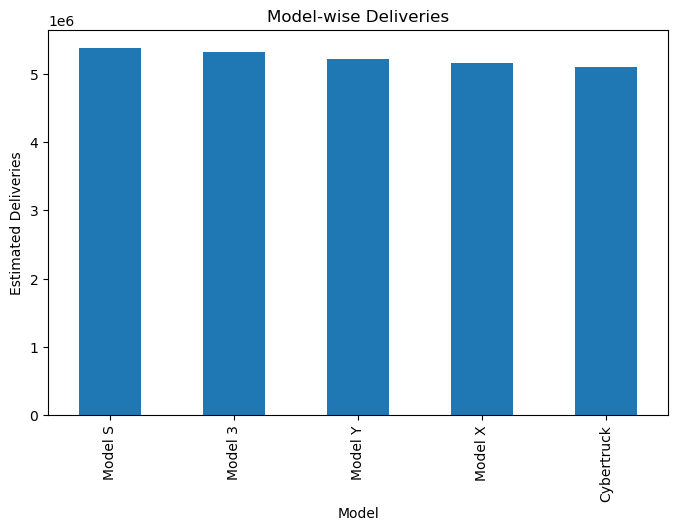

In [13]:
model = (
    df.groupby("Model")["Estimated_Deliveries"]
      .sum()
      .sort_values(ascending=False)
)
plt.figure(figsize=(8,5))
model.plot(kind="bar")
plt.title("Model-wise Deliveries")
plt.ylabel("Estimated Deliveries")
plt.show()

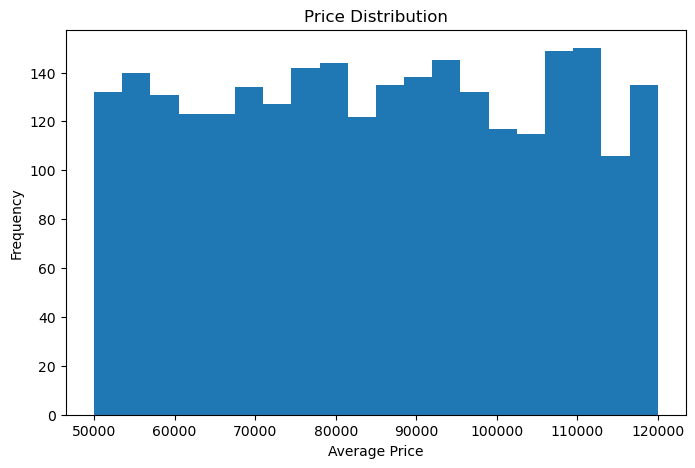

In [14]:
plt.figure(figsize=(8,5))
plt.hist(df["Avg_Price_USD"], bins=20)
plt.title("Price Distribution")
plt.xlabel("Average Price")
plt.ylabel("Frequency")
plt.show()

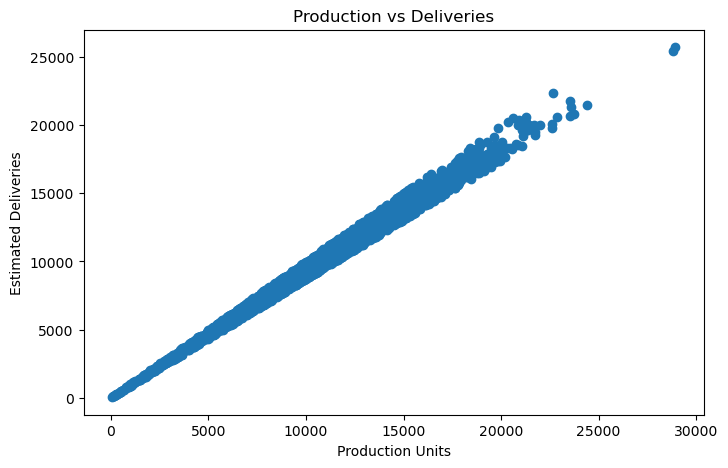

In [15]:
plt.figure(figsize=(8,5))
plt.scatter(
    df["Production_Units"],
    df["Estimated_Deliveries"]
)
plt.xlabel("Production Units")
plt.ylabel("Estimated Deliveries")
plt.title("Production vs Deliveries")
plt.show()

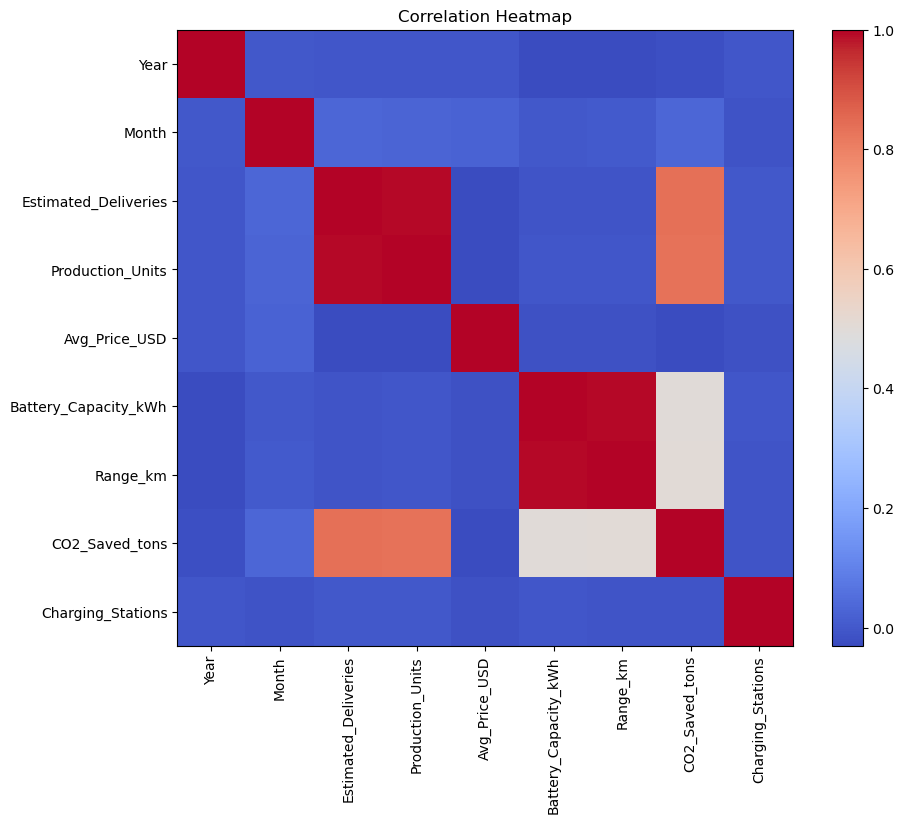

In [16]:
corr = df.select_dtypes(include=np.number).corr()
plt.figure(figsize=(10,8))
plt.imshow(corr, cmap="coolwarm")
plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)
plt.yticks(
    range(len(corr.columns)),
    corr.columns
)
plt.colorbar()
plt.title("Correlation Heatmap")
plt.show()

In [17]:
# Feature Engineering

df["Production_Gap"] = (
    df["Production_Units"] -
    df["Estimated_Deliveries"]
)

df["Delivery_per_Station"] = (
    df["Estimated_Deliveries"] /
    df["Charging_Stations"]
)


In [18]:
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Production_Gap,Delivery_per_Station
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207,276,1.445564
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640,367,0.496990
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071,778,0.597754
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333,756,0.702347
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722,1163,1.418711


In [19]:
# Data Preprocessing

X = df.drop(columns=["Estimated_Deliveries"])
y = df["Estimated_Deliveries"]

In [20]:
categorical_features = [
    "Region",
    "Model",
    "Source_Type"
]

numerical_features = [
    col
    for col in X.columns
    if col not in categorical_features
]

In [21]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

In [22]:
# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [23]:
# Regression Model

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(random_state=42))
    ]
)

In [24]:
pipeline.fit(
    X_train,
    y_train
)

/Users/kaushalpokarne/Documents/Anaconda/anaconda3/lib/python3.13/site-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Region', 'Model',
                                                   'Source_Type'])])),
                ('model', RandomForestRegressor(random_state=42))])

In [25]:
y_pred = pipeline.predict(X_test)

In [26]:
# Model Evaluation

mae = mean_absolute_error(
    y_test,
    y_pred
)

mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    y_pred
)

print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

MAE  : 71.35
MSE  : 12601.06
RMSE : 112.25
R²   : 0.9992


In [27]:
# Hyperparameter Tuning

param_grid = {

    "model__n_estimators": [
        100,
        200
    ],

    "model__max_depth": [
        5,
        10,
        None
    ]
}

In [28]:
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

In [29]:
grid_search.fit(
    X_train,
    y_train
)

/Users/kaushalpokarne/Documents/Anaconda/anaconda3/lib/python3.13/site-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['Region',
                                                                          'Model',
                                                                          'Source_Type'])])),
                                       ('model',
                                        RandomForestRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [5, 10, None],
                         'model__n_estimators': [100, 200]},
             scoring='r2')

In [30]:
print(
    "Best Parameters:",
    grid_search.best_params_
)

print(
    "Best CV Score:",
    grid_search.best_score_
)

Best Parameters: {'model__max_depth': None, 'model__n_estimators': 100}
Best CV Score: 0.9981375528827799


In [31]:
best_model = grid_search.best_estimator_

best_predictions = best_model.predict(
    X_test
)

In [32]:
print(
    "MAE:",
    mean_absolute_error(
        y_test,
        best_predictions
    )
)

print(
    "RMSE:",
    np.sqrt(
        mean_squared_error(
            y_test,
            best_predictions
        )
    )
)

print(
    "R²:",
    r2_score(
        y_test,
        best_predictions
    )
)

MAE: 71.35363636363637
RMSE: 112.25443015992863
R²: 0.9991546482278216


In [33]:
# Time Series Forecasting

df["Date"] = pd.to_datetime(
    df["Year"].astype(str) + "-" +
    df["Month"].astype(str) + "-01"
)

In [34]:
monthly = (
    df.groupby("Date")["Estimated_Deliveries"]
      .sum()
)

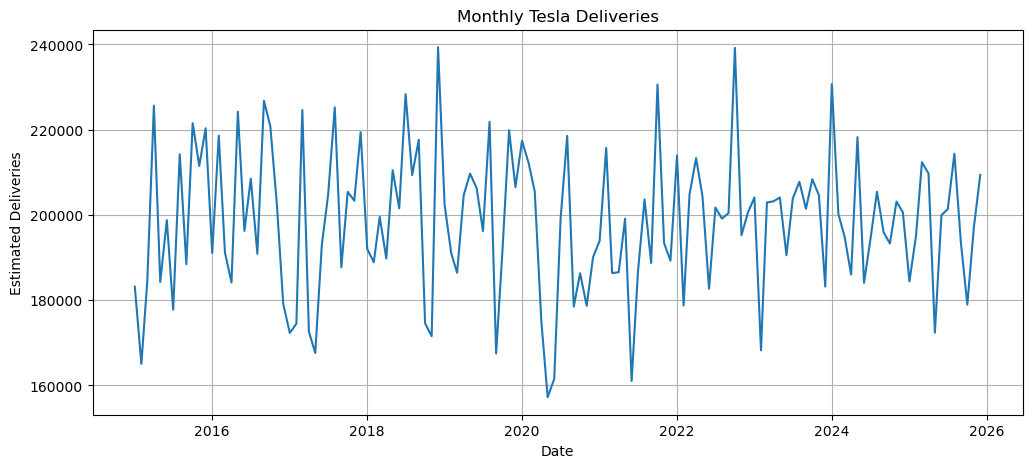

In [35]:
plt.figure(figsize=(12,5))
plt.plot(monthly.index, monthly.values)
plt.title("Monthly Tesla Deliveries")
plt.xlabel("Date")
plt.ylabel("Estimated Deliveries")
plt.grid(True)
plt.show()

In [36]:
from sklearn.linear_model import LinearRegression

In [37]:
time = np.arange(len(monthly)).reshape(-1,1)
target = monthly.values

In [38]:
lr = LinearRegression()
lr.fit(time, target)

LinearRegression()

In [39]:
future_time = np.arange(
    len(monthly),
    len(monthly)+12
).reshape(-1,1)

future_predictions = lr.predict(future_time)

In [40]:
future_dates = pd.date_range(
    start=monthly.index[-1] + pd.offsets.MonthBegin(),
    periods=12,
    freq="MS"
)

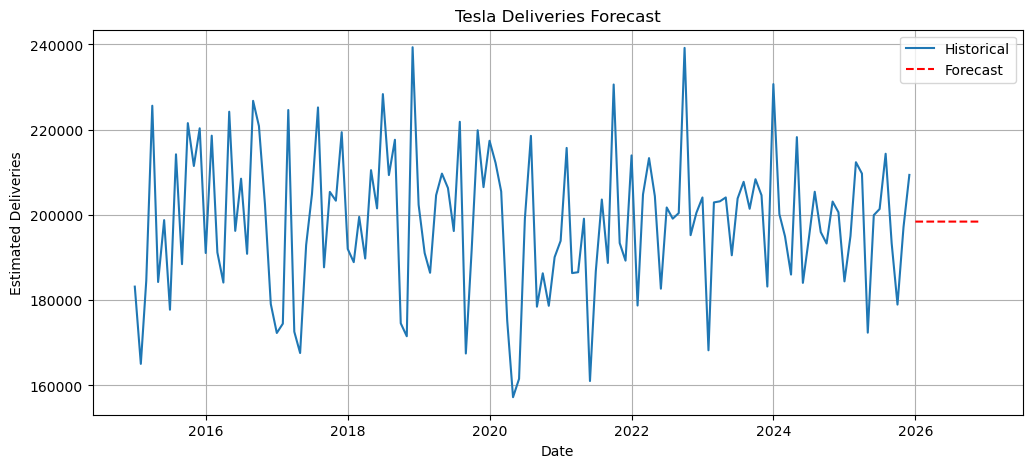

In [41]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly.index,
    monthly.values,
    label="Historical"
)

plt.plot(
    future_dates,
    future_predictions,
    color="red",
    linestyle="--",
    label="Forecast"
)

plt.title("Tesla Deliveries Forecast")
plt.xlabel("Date")
plt.ylabel("Estimated Deliveries")
plt.legend()
plt.grid(True)
plt.show()

In [42]:
forecast = pd.DataFrame({
    "Date": future_dates,
    "Forecast_Deliveries": future_predictions
})

forecast

,Date,Forecast_Deliveries
0,2026-01-01,198436.571015
1,2026-02-01,198436.459415
2,2026-03-01,198436.347815
3,2026-04-01,198436.236215
4,2026-05-01,198436.124615
5,2026-06-01,198436.013015
6,2026-07-01,198435.901415
7,2026-08-01,198435.789815
8,2026-09-01,198435.678214
9,2026-10-01,198435.566614


In [43]:
# Conclusion

print("Project Summary")
print("-"*40)
print("Dataset Shape:", df.shape)
print("Best Model:")
print(type(best_model.named_steps["model"]).__name__)
print("\nModel Performance")
print(f"MAE : {mean_absolute_error(y_test,best_predictions):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test,best_predictions)):.2f}")
print(f"R²  : {r2_score(y_test,best_predictions):.4f}")


Project Summary
----------------------------------------
Dataset Shape: (2640, 15)
Best Model:
RandomForestRegressor

Model Performance
MAE : 71.35
RMSE: 112.25
R²  : 0.9992
